# IndoBERT Text Classification — Training Pipeline v3

**Model:** `indobenchmark/indobert-base-p1`  
**Dataset:** `dataset_merged_final.csv` — 4 kelas: Rendah, Sedang, Tinggi, Unknown  
**Arsitektur pipeline:**

| Tahap | Detail |
|---|---|
| EDA & Preprocessing | Distribusi kelas, normalisasi teks minimalis |
| Near-Duplicate Detection | SequenceMatcher threshold ≥ 0.90 |
| Stratified Split | 80 / 10 / 10 |
| Pipelining Data | HuggingFace `Dataset` + tokenisasi batched `.map()` |
| Imbalance Handling | `CustomTrainer` dengan weighted `CrossEntropyLoss` |
| Hyperparameter Tuning | `trainer.hyperparameter_search` backend `optuna` (5 trials) |
| Evaluasi Akhir | Macro F1, Accuracy, Precision, Recall + Confusion Matrix |


## Cell 1 — Install Dependencies

In [1]:
# Instalasi seluruh dependensi yang dibutuhkan pipeline.
# Jalankan sekali di awal sesi Kaggle / Colab.
!pip install -q \
    transformers \
    datasets==2.19.1 \
    evaluate==0.4.2 \
    optuna==3.6.1 \
    scikit-learn \
    seaborn \
    matplotlib \
    torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 14.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2024.3.1 which is incompatible.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0.3.8 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


## Cell 2 — Imports & Konfigurasi Global

In [2]:
import os
import re
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch
import torch.nn as nn
from difflib import SequenceMatcher

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
)

import evaluate
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)

warnings.filterwarnings("ignore")

# ── Konfigurasi Global ──────────────────────────────────────────────────────
CONFIG = {
    # Path — sesuaikan ke lokasi CSV kamu
    "csv_path"       : "/kaggle/input/datasets/jundansaifulhaq/dataset-merged-final-fix/dataset_merged_final.csv",
    "output_dir"     : "/kaggle/working/results_v3",
    "model_save_dir" : "/kaggle/working/model_final_v3",

    # Model
    "model_name"     : "indobenchmark/indobert-base-p1",
    "num_labels"     : 4,
    "max_length"     : 128,

    # Stratified split
    "test_size"      : 0.10,
    "val_size"       : 0.10,

    # Near-duplicate detection
    "dedup_threshold": 0.75,

    # Regularisasi
    "dropout"        : 0.30,
    "warmup_ratio"   : 0.10,

    # Hyperparameter search (Optuna)
    "n_trials"       : 5,
    "search_epochs"  : 3,    # epochs per trial — lebih pendek untuk efisiensi

    # Final training
    "num_epochs"     : 6,
    "batch_size"     : 16,

    # Reprodusibilitas
    "seed"           : 42,
}

# ── Label Mapping — 4 kelas termasuk Unknown ────────────────────────────────
# CSV menyimpan label dalam lowercase; normalisasi ke Title Case di Cell 3.
LABEL2ID = {"Rendah": 0, "Sedang": 1, "Tinggi": 2, "Unknown": 3}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}

# ── Seed & Device ────────────────────────────────────────────────────────────
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device   : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"Labels   : {LABEL2ID}")
print(f"Model    : {CONFIG['model_name']}")


Device   : cuda
GPU      : Tesla T4
VRAM     : 15.64 GB
Labels   : {'Rendah': 0, 'Sedang': 1, 'Tinggi': 2, 'Unknown': 3}
Model    : indobenchmark/indobert-base-p1


## Cell 3 — Load CSV & Exploratory Data Analysis

Total baris raw     : 1499
Kolom               : ['id_laporan', 'teks_laporan', 'label_prioritas', 'sumber_data']

Missing values per kolom:
id_laporan         0
teks_laporan       0
label_prioritas    1
sumber_data        1

Contoh data:


,id_laporan,teks_laporan,label_prioritas,sumber_data
0,ID-0001,"Min tolong dong diviralkan, tempat pengolahan ...",tinggi,berita
1,ID-0002,"Lapor DLHK, kondisi pengolahan sampah Piyungan...",tinggi,berita
2,ID-0003,"Tolong dong pemerintah, TPS3R yang di Bantul i...",tinggi,berita



1 baris dengan label tidak dikenal -> dihapus

Total baris setelah validasi label : 1498


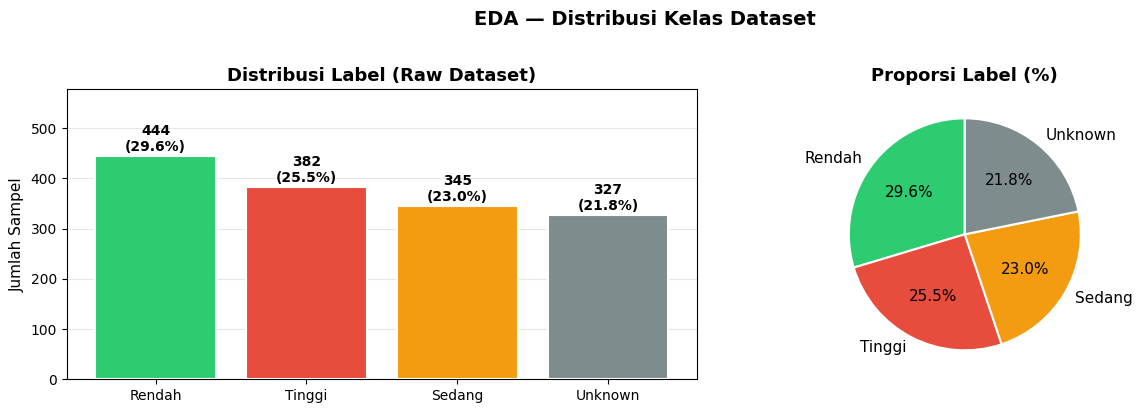


Distribusi label    : {'Rendah': np.int64(444), 'Tinggi': np.int64(382), 'Sedang': np.int64(345), 'Unknown': np.int64(327)}
Imbalance ratio     : 1.36x
Imbalance MINOR — class weights akan diaktifkan saat training.


In [3]:
df = pd.read_csv(CONFIG["csv_path"])

print(f"Total baris raw     : {len(df)}")
print(f"Kolom               : {df.columns.tolist()}")
print(f"\nMissing values per kolom:\n{df.isnull().sum().to_string()}")
print(f"\nContoh data:")
display(df.head(3))

# ── Normalisasi label: lowercase -> Title Case ───────────────────────────────
# CSV menyimpan 'tinggi', 'rendah', 'sedang', 'unknown' (lowercase).
# LABEL2ID menggunakan Title Case → perlu .str.title() sebelum mapping.
df["label_prioritas"] = df["label_prioritas"].str.strip().str.title()

# Hapus baris dengan label di luar domain yang dikenal
valid_labels = set(LABEL2ID.keys())
invalid_mask = ~df["label_prioritas"].isin(valid_labels)
if invalid_mask.sum() > 0:
    print(f"\n{invalid_mask.sum()} baris dengan label tidak dikenal -> dihapus")
    df = df[~invalid_mask].reset_index(drop=True)

print(f"\nTotal baris setelah validasi label : {len(df)}")

# ── Visualisasi Distribusi Label ─────────────────────────────────────────────
label_counts = df["label_prioritas"].value_counts()
PALETTE = {"Tinggi": "#e74c3c", "Sedang": "#f39c12", "Rendah": "#2ecc71", "Unknown": "#7f8c8d"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart dengan annotation jumlah & persentase
colors = [PALETTE.get(l, "#bdc3c7") for l in label_counts.index]
bars   = axes[0].bar(label_counts.index, label_counts.values, color=colors,
                     edgecolor="white", linewidth=1.5, zorder=3)
axes[0].set_title("Distribusi Label (Raw Dataset)", fontsize=13, fontweight="bold")
axes[0].set_ylim(0, label_counts.max() * 1.30)
axes[0].set_ylabel("Jumlah Sampel", fontsize=11)
axes[0].grid(axis="y", alpha=0.3, zorder=0)
for bar, val in zip(bars, label_counts.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 4,
                 f"{val}\n({pct:.1f}%)",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")

# Pie chart
pie_colors = [PALETTE.get(l, "#bdc3c7") for l in label_counts.index]
wedges, texts, autotexts = axes[1].pie(
    label_counts.values,
    labels=label_counts.index,
    colors=pie_colors,
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 11},
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
axes[1].set_title("Proporsi Label (%)", fontsize=13, fontweight="bold")

plt.suptitle("EDA — Distribusi Kelas Dataset", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Analisis Imbalance ───────────────────────────────────────────────────────
min_c, max_c    = label_counts.min(), label_counts.max()
imbalance_ratio = max_c / min_c

print(f"\nDistribusi label    : {dict(label_counts)}")
print(f"Imbalance ratio     : {imbalance_ratio:.2f}x")

if imbalance_ratio < 1.2:
    print("Dataset SEIMBANG — class weights tetap dihitung sebagai safeguard.")
elif imbalance_ratio < 1.5:
    print("Imbalance MINOR — class weights akan diaktifkan saat training.")
else:
    print("Imbalance SIGNIFIKAN — class weights wajib digunakan.")


## Cell 4 — Near-Duplicate Detection & Removal

Scanning near-duplicates (threshold >= 0.75)...
Perbandingan berbasis 200 karakter pertama teks

Ditemukan   : 20 pasangan near-duplicate
Akan dihapus: 20 baris (keep first, drop later)

TOP-10 PASANGAN PALING MIRIP
------------------------------------------------------------
[ID-1098 vs ID-1101]  sim=0.995
  A: Malam min, mau cerita sore ini sekitar jam 18.15 saya hampir kesrempet gara-gara BRIO...
  B: Malam min, mau cerita sore ini sekitar jam 18.15 saya hampir kesrempet gara-gara BRIO...

[ID-1175 vs ID-1236]  sim=0.985
  A: Min tolong info ke dinas sosial atau petugas keamanan. Di perempatan jalan kaliurang ...
  B: Min tolong infokan ke dinas sosial atau petugas keamanan. Di perempatan jalan kaliura...

[ID-1185 vs ID-1225]  sim=0.97
  A: Min ijin lapor, telah hilang sepeda lipat merk pacific warna kuning stabilo di parkir...
  B: Min izin melapor, telah hilang sepeda lipat merk pacific warna kuning stabilo di park...

[ID-1008 vs ID-1048]  sim=0.909
  A: Njir ini udah parah bang

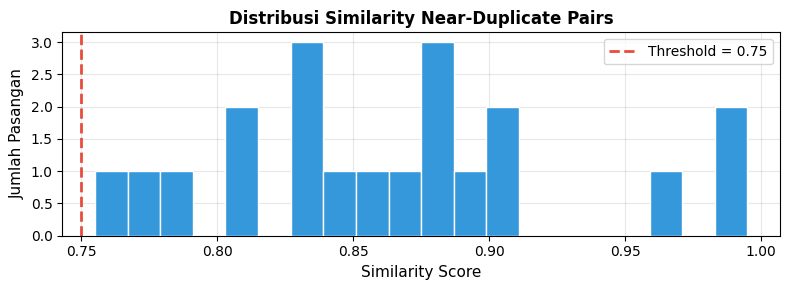


Sebelum dedup : 1498 baris
Setelah dedup : 1478 baris  (-20)

Distribusi label setelah dedup:
label_prioritas
Rendah     444
Tinggi     372
Sedang     339
Unknown    323


In [4]:
# Near-duplicate terjadi karena data LLM-generated menggunakan template yang sama
# dengan hanya nama lokasi yang diganti. Pasangan seperti ini menyebabkan data leakage
# jika template yang sama masuk ke train sekaligus ke val/test.
#
# Strategi: bandingkan 200 karakter pertama teks (bagian paling berulang).
# Jika similarity >= threshold, hapus instance yang lebih akhir (keep first).

THRESHOLD = CONFIG["dedup_threshold"]

print(f"Scanning near-duplicates (threshold >= {THRESHOLD})...")
print(f"Perbandingan berbasis 200 karakter pertama teks\n")

texts   = df["teks_laporan"].tolist()
ids     = df["id_laporan"].tolist()
n_raw   = len(texts)
to_drop = set()
dup_log = []

for i in range(n_raw):
    for j in range(i + 1, n_raw):
        if j in to_drop:
            continue
        ratio = SequenceMatcher(None, texts[i][:200], texts[j][:200]).ratio()
        if ratio >= THRESHOLD:
            to_drop.add(j)
            dup_log.append({
                "id_a"  : ids[i],
                "id_b"  : ids[j],
                "sim"   : round(ratio, 3),
                "text_a": texts[i][:85] + "...",
                "text_b": texts[j][:85] + "...",
            })

if dup_log:
    df_log = pd.DataFrame(dup_log).sort_values("sim", ascending=False)
    print(f"Ditemukan   : {len(dup_log)} pasangan near-duplicate")
    print(f"Akan dihapus: {len(to_drop)} baris (keep first, drop later)\n")

    print("TOP-10 PASANGAN PALING MIRIP")
    print("-" * 60)
    for _, row in df_log.head(10).iterrows():
        print(f"[{row['id_a']} vs {row['id_b']}]  sim={row['sim']}")
        print(f"  A: {row['text_a']}")
        print(f"  B: {row['text_b']}")
        print()

    # Visualisasi distribusi similarity score
    sims = df_log["sim"].tolist()
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(sims, bins=20, color="#3498db", edgecolor="white", zorder=3)
    ax.axvline(THRESHOLD, color="#e74c3c", linestyle="--", linewidth=2,
               label=f"Threshold = {THRESHOLD}")
    ax.set_xlabel("Similarity Score", fontsize=11)
    ax.set_ylabel("Jumlah Pasangan", fontsize=11)
    ax.set_title("Distribusi Similarity Near-Duplicate Pairs", fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3, zorder=0)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada near-duplicate ditemukan.")

# Terapkan filter
keep_mask = [i not in to_drop for i in range(n_raw)]
df_clean  = df[keep_mask].reset_index(drop=True)

print(f"\nSebelum dedup : {n_raw} baris")
print(f"Setelah dedup : {len(df_clean)} baris  (-{n_raw - len(df_clean)})")
print(f"\nDistribusi label setelah dedup:")
print(df_clean["label_prioritas"].value_counts().to_string())


## Cell 5 — Text Preprocessing

In [5]:
def clean_text(text: str) -> str:
    """
    Preprocessing minimalis — sengaja tidak agresif.

    Pendekatan ini mempertahankan slang, singkatan, dan bahasa kasual karena:
      1. Dataset berisi laporan warga dengan bahasa informal/gaul
      2. IndoBERT menangani OOV melalui subword tokenisasi (WordPiece)
      3. Stemming dan stop-word removal merusak sinyal semantik kalimat

    Yang dibersihkan:
      - Karakter kontrol Unicode (\x00-\x1f, \x7f-\x9f)
      - Baris baru dan tab -> diganti spasi
      - Simbol non-relevan di luar alfanumerik dan tanda baca umum
      - Spasi ganda berlebih
    """
    if not isinstance(text, str):
        return ""
    # Hapus karakter kontrol
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f-\x9f]", "", text)
    # Normalisasi whitespace
    text = re.sub(r"[\r\n\t]+", " ", text)
    # Pertahankan alfanumerik, tanda baca umum, dan Unicode (aksara Jawa, dll.)
    text = re.sub(r"[^\w\s.,!?;:\-\'\"()/]", " ", text, flags=re.UNICODE)
    text = re.sub(r" {2,}", " ", text).strip()
    return text.lower()


# Terapkan ke seluruh dataset bersih
df_clean = df_clean.copy()
df_clean["teks_bersih"] = df_clean["teks_laporan"].apply(clean_text)
df_clean["label"]       = df_clean["label_prioritas"].map(LABEL2ID)

# Sanity check: tidak boleh ada NaN setelah mapping
n_nan = df_clean["label"].isna().sum()
assert n_nan == 0, f"{n_nan} label NaN terdeteksi — periksa LABEL2ID vs nilai CSV"
print("Label mapping valid — tidak ada NaN\n")

# Preview contoh per kelas
print("CONTOH TEKS PER KELAS (setelah clean)")
print("=" * 65)
for label_name in LABEL2ID.keys():
    sample_row = df_clean[df_clean["label_prioritas"] == label_name].iloc[0]
    print(f"[{label_name}]")
    print(f"  Original : {sample_row['teks_laporan'][:110]}...")
    print(f"  Cleaned  : {sample_row['teks_bersih'][:110]}...")
    print()


Label mapping valid — tidak ada NaN

CONTOH TEKS PER KELAS (setelah clean)
[Rendah]
  Original : Permisi admin, mau nanya jadwal pengangkutan buat Jalan Nuri RT 04 Jetis minggu ini hari apa aja ya masuknya? ...
  Cleaned  : permisi admin, mau nanya jadwal pengangkutan buat jalan nuri rt 04 jetis minggu ini hari apa aja ya masuknya? ...

[Sedang]
  Original : Ini gimana ceritanya lapangan Pemda Sleman malah berubah jadi TPS dadakan? Pemandangannya kotor banget, baunya...
  Cleaned  : ini gimana ceritanya lapangan pemda sleman malah berubah jadi tps dadakan? pemandangannya kotor banget, baunya...

[Tinggi]
  Original : Min tolong dong diviralkan, tempat pengolahan sampah di Bantul baunya makin naudzubillah. Warga udah ga tahan ...
  Cleaned  : min tolong dong diviralkan, tempat pengolahan sampah di bantul baunya makin naudzubillah. warga udah ga tahan ...

[Unknown]
  Original : jl kebon agung sore ini hujan badai hati hati bagi pengendara yang melintas banyak pohon tua dan ada beberapa 

## Cell 6 — Stratified Split 80 / 10 / 10

Stratified Split (total: 1478 baris)
  Train :  1182 (80.0%)
  Val   :   148 (10.0%)
  Test  :   148 (10.0%)


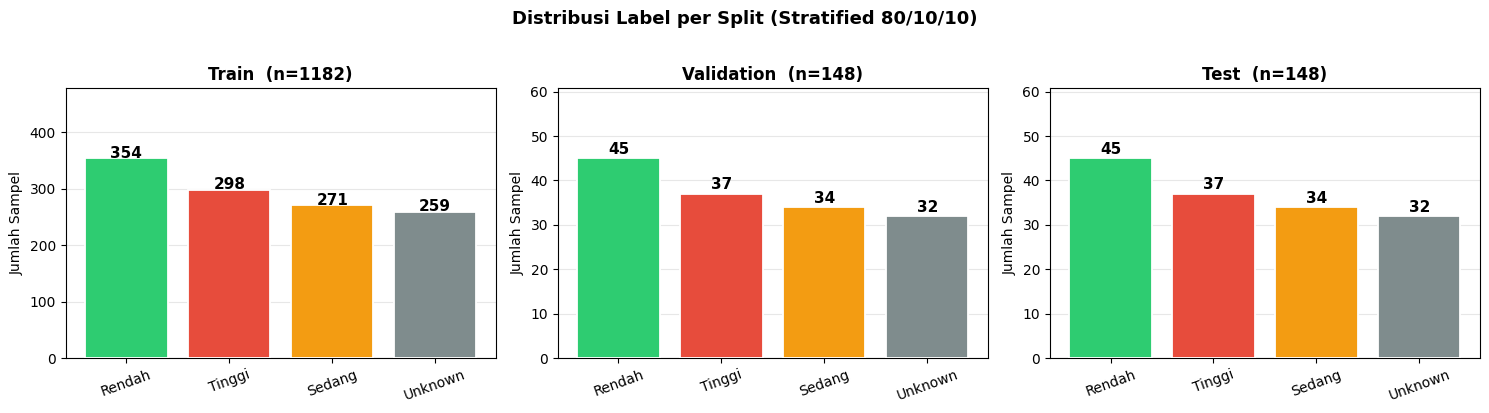


Train:
label_prioritas
Rendah     354
Tinggi     298
Sedang     271
Unknown    259

Validation:
label_prioritas
Rendah     45
Tinggi     37
Sedang     34
Unknown    32

Test:
label_prioritas
Rendah     45
Tinggi     37
Sedang     34
Unknown    32


In [6]:
# Stratified split memastikan proporsi setiap kelas (Rendah, Sedang, Tinggi, Unknown)
# sama di split train, val, dan test.
# Rasio 80/10/10 dipilih untuk memaksimalkan data training.

TEST_SIZE = CONFIG["test_size"]   # 0.10
VAL_SIZE  = CONFIG["val_size"]    # 0.10

# Step 1: pisahkan test set (10%)
df_trainval, df_test = train_test_split(
    df_clean,
    test_size=TEST_SIZE,
    stratify=df_clean["label_prioritas"],
    random_state=CONFIG["seed"],
)

# Step 2: dari sisa trainval, pisahkan val
# val_ratio = 0.10 / 0.90 ≈ 0.111 agar val = 10% dari total
val_ratio = VAL_SIZE / (1 - TEST_SIZE)
df_train, df_val = train_test_split(
    df_trainval,
    test_size=val_ratio,
    stratify=df_trainval["label_prioritas"],
    random_state=CONFIG["seed"],
)

print(f"Stratified Split (total: {len(df_clean)} baris)")
print(f"  Train : {len(df_train):>5} ({len(df_train)/len(df_clean)*100:.1f}%)")
print(f"  Val   : {len(df_val):>5} ({len(df_val)/len(df_clean)*100:.1f}%)")
print(f"  Test  : {len(df_test):>5} ({len(df_test)/len(df_clean)*100:.1f}%)")

# ── Visualisasi distribusi per split ────────────────────────────────────────
splits = [("Train", df_train), ("Validation", df_val), ("Test", df_test)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, df_split) in zip(axes, splits):
    counts = df_split["label_prioritas"].value_counts()
    colors = [PALETTE.get(l, "#bdc3c7") for l in counts.index]
    bars   = ax.bar(counts.index, counts.values, color=colors,
                    edgecolor="white", linewidth=1.3, zorder=3)
    ax.set_title(f"{title}  (n={len(df_split)})", fontsize=12, fontweight="bold")
    ax.set_ylim(0, counts.max() * 1.35)
    ax.set_ylabel("Jumlah Sampel", fontsize=10)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                str(val), ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Distribusi Label per Split (Stratified 80/10/10)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Detail per kelas per split
for name, df_split in splits:
    print(f"\n{name}:")
    print(df_split["label_prioritas"].value_counts().to_string())


## Cell 7 — Perhitungan Class Weights

In [7]:
# Class weights memberikan bobot lebih besar pada kelas yang lebih sedikit,
# sehingga model tidak bias ke kelas mayoritas saat training.
# Dihitung hanya dari train set untuk menghindari leakage dari val/test.

train_labels_int = df_train["label"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(LABEL2ID.values())),
    y=train_labels_int,
)

# Simpan sebagai tensor PyTorch di device yang sesuai
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print("Class Weights (digunakan di CustomTrainer -> CrossEntropyLoss):")
print("-" * 50)
print(f"{'Label':<12} {'ID':<5} {'Weight':<10} Visualisasi")
print("-" * 50)
for label_id in sorted(ID2LABEL.keys()):
    label_name = ID2LABEL[label_id]
    weight     = class_weights[label_id]
    bar        = "#" * int(weight * 25)
    print(f"{label_name:<12} {label_id:<5} {weight:<10.4f} {bar}")

n_per_class = pd.Series(train_labels_int).value_counts().sort_index()
print("\nJumlah sampel per kelas di train set:")
for cls_id, n in n_per_class.items():
    print(f"  {ID2LABEL[cls_id]:<10} : {n} sampel")

print(f"\nCatatan: weight > 1.0 = kelas minoritas (gradient diperbesar)")
print(f"         weight < 1.0 = kelas mayoritas (gradient diperkecil)")
print(f"\nTensor: shape={CLASS_WEIGHTS_TENSOR.shape} | device={CLASS_WEIGHTS_TENSOR.device}")


Class Weights (digunakan di CustomTrainer -> CrossEntropyLoss):
--------------------------------------------------
Label        ID    Weight     Visualisasi
--------------------------------------------------
Rendah       0     0.8347     ####################
Sedang       1     1.0904     ###########################
Tinggi       2     0.9916     ########################
Unknown      3     1.1409     ############################

Jumlah sampel per kelas di train set:
  Rendah     : 354 sampel
  Sedang     : 271 sampel
  Tinggi     : 298 sampel
  Unknown    : 259 sampel

Catatan: weight > 1.0 = kelas minoritas (gradient diperbesar)
         weight < 1.0 = kelas mayoritas (gradient diperkecil)

Tensor: shape=torch.Size([4]) | device=cuda:0


## Cell 8 — Tokenisasi & HuggingFace Dataset

In [8]:
print(f"Memuat tokenizer: {CONFIG['model_name']}")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
print(f"Vocab size: {tokenizer.vocab_size:,}")

def tokenize_fn(examples: dict) -> dict:
    """
    Tokenisasi teks menggunakan tokenizer IndoBERT.
    Menggunakan truncation=True tanpa padding di sini karena padding
    ditangani secara dinamis oleh DataCollatorWithPadding (lebih efisien).
    """
    return tokenizer(
        examples["teks_bersih"],
        truncation=True,
        max_length=CONFIG["max_length"],
    )


def df_to_hf(df_split: pd.DataFrame, split_name: str = "") -> Dataset:
    """
    Konversi DataFrame ke HuggingFace Dataset dan lakukan tokenisasi
    secara batched untuk efisiensi memori.

    Kolom 'labels' (bukan 'label') digunakan karena Trainer HuggingFace
    secara default mencari kolom bernama 'labels' untuk loss computation.
    """
    ds = Dataset.from_dict({
        "teks_bersih": df_split["teks_bersih"].tolist(),
        "labels"     : df_split["label"].astype(int).tolist(),
    })
    desc = f"Tokenisasi [{split_name}]" if split_name else "Tokenisasi"
    ds   = ds.map(
        tokenize_fn,
        batched=True,
        batch_size=64,
        desc=desc,
    )
    # Hapus kolom teks mentah — tidak dibutuhkan saat training
    ds = ds.remove_columns(["teks_bersih"])
    return ds


# DataCollatorWithPadding menerapkan dynamic padding per batch
# lebih hemat memori dibandingkan padding ke max_length secara statis
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("\nMemproses split ke HuggingFace Dataset...")
train_dataset = df_to_hf(df_train, "train")
val_dataset   = df_to_hf(df_val,   "val")
test_dataset  = df_to_hf(df_test,  "test")

print("\nDataset HuggingFace siap:")
print(f"  Train : {len(train_dataset):>5} sampel")
print(f"  Val   : {len(val_dataset):>5} sampel")
print(f"  Test  : {len(test_dataset):>5} sampel")
print(f"  Features: {list(train_dataset.features.keys())}")

# Cek distribusi panjang token pada train set
token_lengths = [len(x) for x in train_dataset["input_ids"]]
print(f"\nDistribusi panjang token (train set):")
print(f"  Min    : {min(token_lengths)}")
print(f"  Max    : {max(token_lengths)}")
print(f"  Mean   : {np.mean(token_lengths):.1f}")
print(f"  Median : {np.median(token_lengths):.1f}")
print(f"  P95    : {np.percentile(token_lengths, 95):.1f}")
print(f"  Max length config: {CONFIG['max_length']}")


Memuat tokenizer: indobenchmark/indobert-base-p1


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Vocab size: 30,521

Memproses split ke HuggingFace Dataset...


Tokenisasi [train]:   0%|          | 0/1182 [00:00<?, ? examples/s]

Tokenisasi [val]:   0%|          | 0/148 [00:00<?, ? examples/s]

Tokenisasi [test]:   0%|          | 0/148 [00:00<?, ? examples/s]


Dataset HuggingFace siap:
  Train :  1182 sampel
  Val   :   148 sampel
  Test  :   148 sampel
  Features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']

Distribusi panjang token (train set):
  Min    : 14
  Max    : 128
  Mean   : 57.8
  Median : 58.0
  P95    : 81.0
  Max length config: 128


## Cell 9 — model_init, compute_metrics & CustomTrainer

In [9]:
# ── Metrik evaluasi menggunakan library evaluate ──────────────────────────────
_acc_metric  = evaluate.load("accuracy")
_f1_metric   = evaluate.load("f1")
_prec_metric = evaluate.load("precision")
_rec_metric  = evaluate.load("recall")

def compute_metrics(eval_pred) -> dict:
    """
    Dipanggil di akhir setiap epoch eval oleh Trainer.
    Mengembalikan F1-macro sebagai metrik utama plus Accuracy,
    Precision, dan Recall untuk monitoring komprehensif.
    """
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "f1_macro"       : round(_f1_metric.compute(
                               predictions=preds, references=labels, average="macro")["f1"], 4),
        "accuracy"       : round(_acc_metric.compute(
                               predictions=preds, references=labels)["accuracy"], 4),
        "precision_macro": round(_prec_metric.compute(
                               predictions=preds, references=labels,
                               average="macro", zero_division=0)["precision"], 4),
        "recall_macro"   : round(_rec_metric.compute(
                               predictions=preds, references=labels,
                               average="macro", zero_division=0)["recall"], 4),
    }


# ── model_init — dipanggil ulang setiap trial Optuna ─────────────────────────
def model_init(trial=None) -> AutoModelForSequenceClassification:
    """
    Membuat instance model yang bersih di setiap pemanggilan.
    Diperlukan oleh hyperparameter_search agar setiap trial
    dimulai dari bobot awal yang sama (tidak mewarisi state trial sebelumnya).

    Dropout dinaikkan dari default IndoBERT (0.1) ke 0.3 untuk regularisasi
    tambahan mengingat ukuran dataset yang relatif kecil.
    """
    mdl = AutoModelForSequenceClassification.from_pretrained(
        CONFIG["model_name"],
        num_labels              = CONFIG["num_labels"],
        id2label                = ID2LABEL,
        label2id                = LABEL2ID,
        ignore_mismatched_sizes = True,
    )
    mdl.config.hidden_dropout_prob          = CONFIG["dropout"]
    mdl.config.attention_probs_dropout_prob = CONFIG["dropout"] / 2
    for layer in mdl.bert.encoder.layer:
        layer.attention.self.dropout.p   = mdl.config.attention_probs_dropout_prob
        layer.attention.output.dropout.p = mdl.config.hidden_dropout_prob
        layer.output.dropout.p           = mdl.config.hidden_dropout_prob
    return mdl


# ── CustomTrainer dengan Weighted CrossEntropyLoss ────────────────────────────
class CustomTrainer(Trainer):
    """
    Subclass Trainer yang meng-override compute_loss untuk menyuntikkan
    class weights ke CrossEntropyLoss.

    Kelas minoritas mendapat gradient yang lebih besar, mencegah model
    bias ke kelas mayoritas — penting untuk dataset yang tidak seimbang.

    CLASS_WEIGHTS_TENSOR harus didefinisikan sebelum trainer dibuat (Cell 7).
    """

    def compute_loss(self, model, inputs, return_outputs: bool = False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.logits
        # Pindahkan weight tensor ke device yang sama dengan logits
        # (penting untuk multi-GPU atau saat device berubah antar trial)
        loss_fn = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS_TENSOR.to(logits.device))
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


print("Setup selesai:")
print(f"  Metrik utama     : Macro F1 (eval_f1_macro)")
print(f"  Metrik tambahan  : Accuracy, Precision (macro), Recall (macro)")
print(f"  Loss function    : CrossEntropyLoss dengan class weights")
print(f"  Dropout override : hidden={CONFIG['dropout']}, attn={CONFIG['dropout']/2}")
print(f"  model_init       : Siap untuk Optuna hyperparameter_search")


Setup selesai:
  Metrik utama     : Macro F1 (eval_f1_macro)
  Metrik tambahan  : Accuracy, Precision (macro), Recall (macro)
  Loss function    : CrossEntropyLoss dengan class weights
  Dropout override : hidden=0.3, attn=0.15
  model_init       : Siap untuk Optuna hyperparameter_search


## Cell 10 — Hyperparameter Search dengan Optuna

In [10]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

os.makedirs(CONFIG["output_dir"] + "/hp_search", exist_ok=True)

# ── Hyperparameter Search Space ───────────────────────────────────────────────
# Tiga parameter yang paling berdampak untuk fine-tuning BERT:
#   - learning_rate   : faktor terpenting, log-scale untuk eksplorasi rentang lebar
#   - weight_decay    : regularisasi L2 untuk mencegah overfit
#   - num_train_epochs: durasi training per trial (dibatasi 3-5 agar efisien)
#
# Batch size sengaja tidak dimasukkan ke search space agar trial tidak terlalu
# bervariasi (pada GPU Kaggle, batch size 16 sudah optimal untuk IndoBERT-base).

def hp_space(trial: optuna.Trial) -> dict:
    return {
        "learning_rate"   : trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "weight_decay"    : trial.suggest_float("weight_decay", 0.01, 0.30),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 3, 5),
    }

# ── TrainingArguments untuk fase search ──────────────────────────────────────
# save_strategy="no" agar tidak ada checkpoint per trial — hemat disk.
# Nilai default di bawah akan di-override oleh Optuna per trial.
search_args = TrainingArguments(
    output_dir                  = CONFIG["output_dir"] + "/hp_search",
    per_device_train_batch_size = CONFIG["batch_size"],
    per_device_eval_batch_size  = CONFIG["batch_size"],
    warmup_ratio                = CONFIG["warmup_ratio"],
    lr_scheduler_type           = "linear",
    eval_strategy               = "epoch",
    save_strategy               = "no",
    logging_steps               = 100,
    report_to                   = "none",
    seed                        = CONFIG["seed"],
    data_seed                   = CONFIG["seed"],
    fp16                        = torch.cuda.is_available(),
    dataloader_num_workers      = 2,
    # Nilai default — akan di-override oleh Optuna
    learning_rate               = 2e-5,
    weight_decay                = 0.1,
    num_train_epochs            = CONFIG["search_epochs"],
)

# CustomTrainer dengan model_init untuk search
search_trainer = CustomTrainer(
    args            = search_args,
    model_init      = model_init,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    processing_class= tokenizer,
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
)

print(f"Memulai Optuna hyperparameter search ({CONFIG['n_trials']} trials)...")
print(f"Setiap trial melatih model baru dengan hyperparameter berbeda.\n")

best_run = search_trainer.hyperparameter_search(
    direction        = "maximize",
    backend          = "optuna",
    n_trials         = CONFIG["n_trials"],
    hp_space         = hp_space,
    compute_objective= lambda metrics: metrics["eval_f1_macro"],
)

print("\nHyperparameter Search Selesai!")
print(f"  Best objective (F1-macro) : {best_run.objective:.4f}")
print(f"  Best hyperparameters:")
for k, v in best_run.hyperparameters.items():
    print(f"    {k:<30} : {v}")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy,Precision Macro,Recall Macro
1,No log,0.347024,0.888500,0.891900,0.893400,0.885800
2,No log,0.103427,0.957700,0.959500,0.957900,0.958300
3,0.435660,0.113555,0.965100,0.966200,0.965900,0.964400
4,0.435660,0.100740,0.971800,0.973000,0.971800,0.971800


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy,Precision Macro,Recall Macro
1,No log,0.519440,0.867200,0.871600,0.874500,0.864000
2,No log,0.186595,0.929600,0.932400,0.930600,0.929700
3,0.561847,0.146350,0.957500,0.959500,0.958300,0.957200



Hyperparameter Search Selesai!
  Best objective (F1-macro) : 0.9718
  Best hyperparameters:
    learning_rate                  : 3.3212947485581434e-05
    weight_decay                   : 0.03380524887757227
    num_train_epochs               : 4


## Cell 11 — Final Training dengan Best Hyperparameters

In [11]:
best_hp = best_run.hyperparameters

os.makedirs(CONFIG["output_dir"] + "/final", exist_ok=True)

# ── TrainingArguments final menggunakan best hyperparams dari Optuna ──────────
# load_best_model_at_end=True memastikan checkpoint terbaik (berdasarkan
# eval_f1_macro) yang dimuat di akhir, bukan checkpoint epoch terakhir.
final_args = TrainingArguments(
    output_dir                  = CONFIG["output_dir"] + "/final",
    num_train_epochs            = CONFIG["num_epochs"],
    per_device_train_batch_size = CONFIG["batch_size"],
    per_device_eval_batch_size  = CONFIG["batch_size"],
    learning_rate               = best_hp.get("learning_rate", 2e-5),
    weight_decay                = best_hp.get("weight_decay", 0.1),
    warmup_ratio                = CONFIG["warmup_ratio"],
    lr_scheduler_type           = "linear",
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_f1_macro",
    greater_is_better           = True,
    save_total_limit            = 2,
    logging_steps               = 20,
    report_to                   = "none",
    seed                        = CONFIG["seed"],
    data_seed                   = CONFIG["seed"],
    fp16                        = torch.cuda.is_available(),
    dataloader_num_workers      = 2,
)

# Fresh model — mulai dari bobot pretrained, bukan dari state trial sebelumnya
final_model = model_init()

final_trainer = CustomTrainer(
    model           = final_model,
    args            = final_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    processing_class= tokenizer,
    data_collator   = data_collator,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Konfigurasi Final Training:")
print(f"  Max Epochs       : {CONFIG['num_epochs']} (early stop patience=2)")
print(f"  Learning Rate    : {final_args.learning_rate:.2e}  (dari Optuna)")
print(f"  Weight Decay     : {final_args.weight_decay:.4f}  (dari Optuna)")
print(f"  Batch Size       : {final_args.per_device_train_batch_size}")
print(f"  Warmup Ratio     : {final_args.warmup_ratio}")
print(f"  Best Model By    : eval_f1_macro")
print(f"  Mixed Precision  : {torch.cuda.is_available()}\n")

print("Memulai final training...")
train_result = final_trainer.train()

print("\nFinal Training Selesai!")
print(f"  Runtime          : {train_result.metrics.get('train_runtime', 0):.1f}s")
print(f"  Train Loss       : {train_result.metrics.get('train_loss', 0):.4f}")
print(f"  Samples/second   : {train_result.metrics.get('train_samples_per_second', 0):.1f}")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Konfigurasi Final Training:
  Max Epochs       : 6 (early stop patience=2)
  Learning Rate    : 3.32e-05  (dari Optuna)
  Weight Decay     : 0.0338  (dari Optuna)
  Batch Size       : 16
  Warmup Ratio     : 0.1
  Best Model By    : eval_f1_macro
  Mixed Precision  : True

Memulai final training...


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy,Precision Macro,Recall Macro
1,1.179164,0.398967,0.900000,0.905400,0.902100,0.899300
2,0.263078,0.110639,0.943600,0.945900,0.945800,0.943700
3,0.093878,0.089947,0.964800,0.966200,0.964700,0.965000
4,0.026346,0.072902,0.978800,0.979700,0.979300,0.978500
5,0.011769,0.085253,0.978900,0.979700,0.978800,0.979100
6,0.005781,0.094760,0.978900,0.979700,0.978800,0.979100


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Final Training Selesai!
  Runtime          : 100.8s
  Train Loss       : 0.2136
  Samples/second   : 70.3


## Cell 12 — Training Curve & Status Monitor

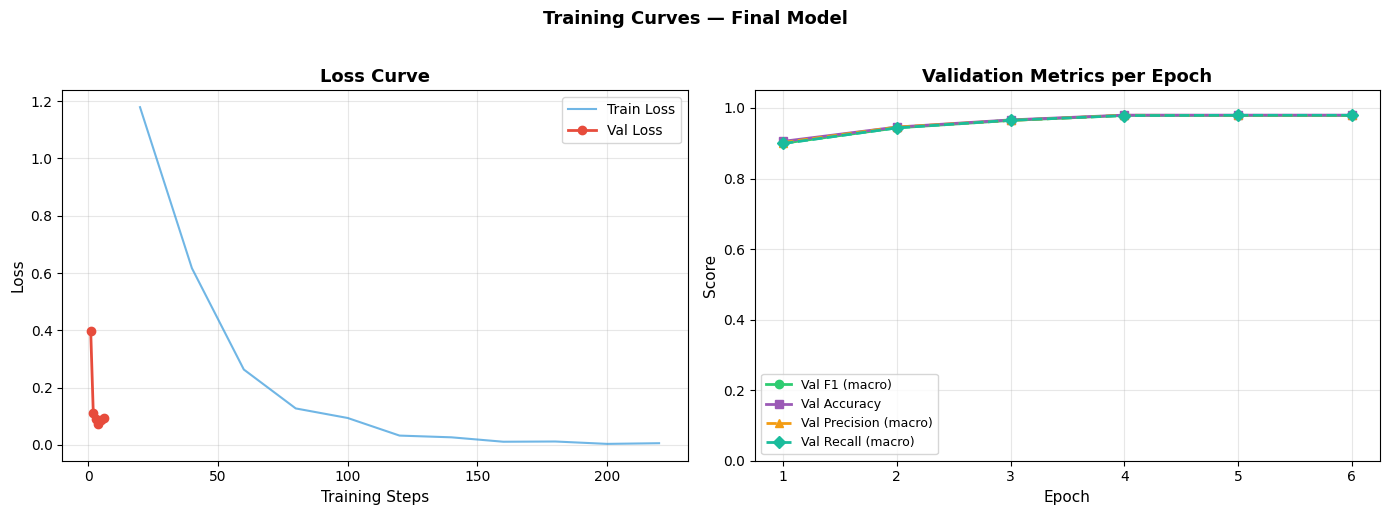

  TRAINING STATUS MONITOR
  Final Train Loss    : 0.0058
  Final Val Loss      : 0.0948
  Relative Gap        : 15.39
  Best Val F1-macro   : 0.9789
  Final Val F1-macro  : 0.9789

  STATUS   : NORMAL
  ANALISIS : Training berjalan baik. Best F1-macro = 0.9789.
  Catatan  : Val loss naik di epoch terakhir — early stopping sudah bekerja dengan benar.


In [12]:
# ── Ambil log history dari trainer ───────────────────────────────────────────
history     = final_trainer.state.log_history
train_logs  = [h for h in history if "loss" in h and "eval_loss" not in h]
eval_logs   = [h for h in history if "eval_loss" in h]

train_losses = [h["loss"]              for h in train_logs]
eval_losses  = [h["eval_loss"]         for h in eval_logs]
eval_f1s     = [h.get("eval_f1_macro", 0)    for h in eval_logs]
eval_accs    = [h.get("eval_accuracy", 0)    for h in eval_logs]
eval_precs   = [h.get("eval_precision_macro", 0) for h in eval_logs]
eval_recs    = [h.get("eval_recall_macro", 0)    for h in eval_logs]
epochs_list  = [h["epoch"]             for h in eval_logs]

# ── Plot training curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
train_steps = [h["step"] for h in train_logs]
axes[0].plot(train_steps, train_losses, label="Train Loss",
             color="#3498db", alpha=0.7, linewidth=1.5)
if eval_logs:
    step_per_epoch = max(1, len(train_logs) // max(1, len(eval_logs)))
    eval_steps_plt = [i * step_per_epoch for i in range(1, len(eval_logs) + 1)]
    axes[0].plot(eval_steps_plt, eval_losses, label="Val Loss",
                 color="#e74c3c", linewidth=2, marker="o", markersize=6)
axes[0].set_title("Loss Curve", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Training Steps", fontsize=11)
axes[0].set_ylabel("Loss", fontsize=11)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Metrics curve
axes[1].plot(epochs_list, eval_f1s,   label="Val F1 (macro)",       color="#2ecc71",  linewidth=2, marker="o")
axes[1].plot(epochs_list, eval_accs,  label="Val Accuracy",          color="#9b59b6",  linewidth=2, marker="s")
axes[1].plot(epochs_list, eval_precs, label="Val Precision (macro)", color="#f39c12",  linewidth=2, marker="^", linestyle="--")
axes[1].plot(epochs_list, eval_recs,  label="Val Recall (macro)",    color="#1abc9c",  linewidth=2, marker="D", linestyle="--")
axes[1].set_title("Validation Metrics per Epoch", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Score", fontsize=11)
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle("Training Curves — Final Model", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Training Status Monitor ───────────────────────────────────────────────────
# Mendeteksi pola OVERFIT / UNDERFIT / NORMAL dari riwayat training.
print("=" * 60)
print("  TRAINING STATUS MONITOR")
print("=" * 60)

if eval_logs and train_logs:
    final_train_loss = train_losses[-1]
    final_val_loss   = eval_losses[-1]
    final_val_f1     = eval_f1s[-1]
    best_val_f1      = max(eval_f1s)
    rel_gap          = (final_val_loss - final_train_loss) / (final_train_loss + 1e-9)

    print(f"  Final Train Loss    : {final_train_loss:.4f}")
    print(f"  Final Val Loss      : {final_val_loss:.4f}")
    print(f"  Relative Gap        : {rel_gap:.2f}")
    print(f"  Best Val F1-macro   : {best_val_f1:.4f}")
    print(f"  Final Val F1-macro  : {final_val_f1:.4f}")
    print()

    # Deteksi status
    if final_train_loss > 0.6 and final_val_f1 < 0.5:
        STATUS = "UNDERFIT"
        DESC   = ("Model belum cukup belajar. "
                  "Coba: tambah epoch, kurangi dropout, atau perbesar dataset.")
    elif rel_gap > 0.5 and final_val_f1 < best_val_f1 - 0.05:
        STATUS = "OVERFIT"
        DESC   = ("Val loss jauh di atas train loss dan F1 turun di akhir. "
                  "Early stopping sudah bekerja. "
                  "Pertimbangkan: naikkan dropout, atau tambah data asli.")
    elif final_val_f1 >= 0.70:
        STATUS = "NORMAL"
        DESC   = f"Training berjalan baik. Best F1-macro = {best_val_f1:.4f}."
    elif final_val_f1 >= 0.50:
        STATUS = "NORMAL (belum optimal)"
        DESC   = "Training stabil namun F1 masih dapat ditingkatkan melalui iterasi."
    else:
        STATUS = "PERLU INVESTIGASI"
        DESC   = ("F1 rendah. Kemungkinan: masalah pada label, distribusi kelas, "
                  "atau teks terlalu pendek untuk konteks model.")

    print(f"  STATUS   : {STATUS}")
    print(f"  ANALISIS : {DESC}")

    # Tips berdasarkan trend
    if len(eval_losses) >= 3 and eval_losses[-1] > eval_losses[-2]:
        print("  Catatan  : Val loss naik di epoch terakhir — early stopping sudah bekerja dengan benar.")
    if len(eval_f1s) >= 2 and eval_f1s[-1] > eval_f1s[-2]:
        print("  Catatan  : Val F1 masih naik di epoch terakhir — pertimbangkan menambah 1-2 epoch.")
else:
    print("  Log history tidak tersedia — jalankan ulang Cell 11.")

print("=" * 60)


## Cell 13 — Evaluasi Akhir pada Test Set

  EVALUASI FINAL — TEST SET
  Macro F1-Score       : 0.9782  (97.82%)
  Accuracy             : 0.9797  (97.97%)
  Macro Precision      : 0.9782
  Macro Recall         : 0.9797

  F1-Score per Kelas:
    Rendah     : 1.0000  [###################################]
    Sedang     : 0.9855  [################################## ]
    Tinggi     : 0.9577  [#################################  ]
    Unknown    : 0.9697  [#################################  ]

  Classification Report:

              precision    recall  f1-score   support

      Rendah       1.00      1.00      1.00        45
      Sedang       0.97      1.00      0.99        34
      Tinggi       1.00      0.92      0.96        37
     Unknown       0.94      1.00      0.97        32

    accuracy                           0.98       148
   macro avg       0.98      0.98      0.98       148
weighted avg       0.98      0.98      0.98       148



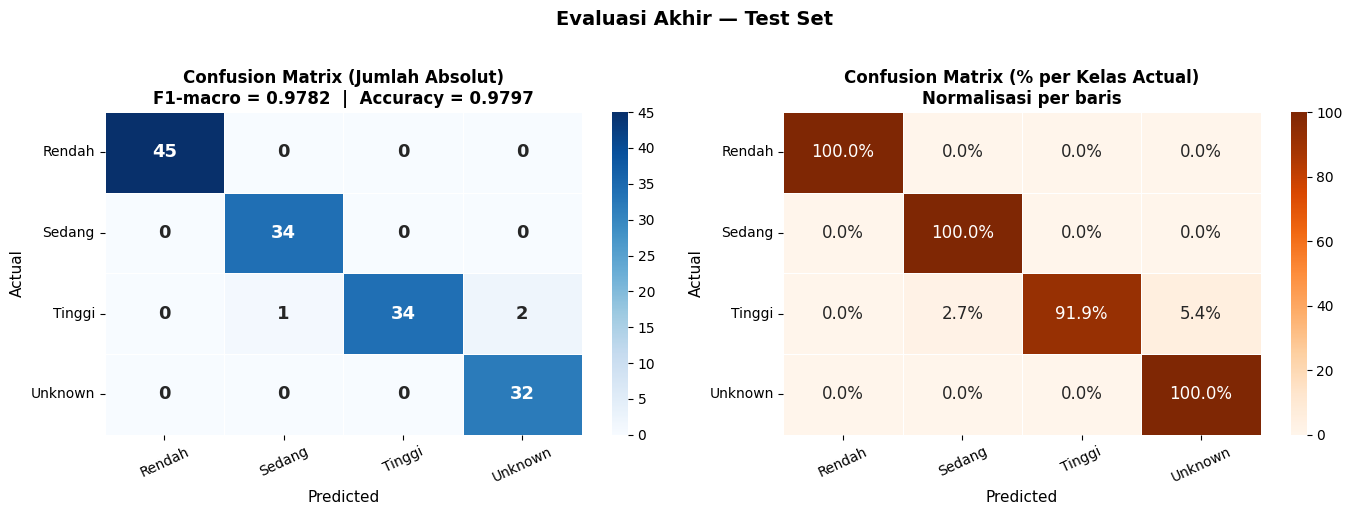


  PERFORMA SANGAT BAIK — Model siap untuk deployment


In [13]:
best_model = final_trainer.model
best_model.eval()

# ── Prediksi test set ─────────────────────────────────────────────────────────
test_output = final_trainer.predict(test_dataset)
logits      = test_output.predictions
true_labels = test_output.label_ids
pred_ids    = np.argmax(logits, axis=-1)

class_names = [ID2LABEL[i] for i in sorted(ID2LABEL.keys())]
true_names  = [ID2LABEL[i] for i in true_labels]
pred_names  = [ID2LABEL[i] for i in pred_ids]

# ── Hitung metrik final ───────────────────────────────────────────────────────
f1_macro   = f1_score(true_labels, pred_ids, average="macro",      zero_division=0)
f1_per_cls = f1_score(true_labels, pred_ids, average=None,
                      labels=sorted(ID2LABEL.keys()),               zero_division=0)
accuracy   = accuracy_score(true_labels, pred_ids)
precision  = precision_score(true_labels, pred_ids, average="macro", zero_division=0)
recall     = recall_score(true_labels, pred_ids, average="macro",    zero_division=0)

print("=" * 60)
print("  EVALUASI FINAL — TEST SET")
print("=" * 60)
print(f"  Macro F1-Score       : {f1_macro:.4f}  ({f1_macro*100:.2f}%)")
print(f"  Accuracy             : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Macro Precision      : {precision:.4f}")
print(f"  Macro Recall         : {recall:.4f}")
print()
print("  F1-Score per Kelas:")
bar_max = 35
for i, name in enumerate(class_names):
    score = f1_per_cls[i]
    bar   = "#" * int(score * bar_max)
    print(f"    {name:<10} : {score:.4f}  [{bar:<{bar_max}}]")

print(f"\n  Classification Report:\n")
print(classification_report(true_names, pred_names,
                             target_names=class_names, zero_division=0))

# ── Confusion Matrix (Count + Percentage) ────────────────────────────────────
cm     = confusion_matrix(true_labels, pred_ids, labels=sorted(ID2LABEL.keys()))
cm_pct = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix — jumlah absolut
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", linewidths=0.6,
    xticklabels=class_names, yticklabels=class_names, ax=axes[0],
    annot_kws={"size": 13, "fontweight": "bold"},
)
axes[0].set_title(
    f"Confusion Matrix (Jumlah Absolut)\nF1-macro = {f1_macro:.4f}  |  Accuracy = {accuracy:.4f}",
    fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Predicted", fontsize=11)
axes[0].set_ylabel("Actual", fontsize=11)
axes[0].tick_params(axis="x", rotation=25)
axes[0].tick_params(axis="y", rotation=0)

# Confusion Matrix — persentase per kelas actual (normalisasi per baris)
annot_pct = np.array([
    [f"{v:.1f}%" for v in row] for row in cm_pct
])
sns.heatmap(
    cm_pct, annot=annot_pct, fmt="", cmap="Oranges", linewidths=0.6,
    xticklabels=class_names, yticklabels=class_names, ax=axes[1],
    annot_kws={"size": 12},
    vmin=0, vmax=100,
)
axes[1].set_title(
    "Confusion Matrix (% per Kelas Actual)\nNormalisasi per baris",
    fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Predicted", fontsize=11)
axes[1].set_ylabel("Actual", fontsize=11)
axes[1].tick_params(axis="x", rotation=25)
axes[1].tick_params(axis="y", rotation=0)

plt.suptitle("Evaluasi Akhir — Test Set", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Verdict ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
if f1_macro >= 0.80:
    print("  PERFORMA SANGAT BAIK — Model siap untuk deployment")
elif f1_macro >= 0.65:
    print("  PERFORMA BAIK — Model layak pakai, masih dapat ditingkatkan")
elif f1_macro >= 0.50:
    print("  PERFORMA SEDANG — Perlu iterasi lebih lanjut")
else:
    print("  PERFORMA RENDAH — Periksa data, label, atau strategi training")
print("=" * 60)


## Cell 14 — Simpan Model & Metadata

In [14]:
SAVE_DIR = CONFIG["model_save_dir"]
os.makedirs(SAVE_DIR, exist_ok=True)

# Pindahkan ke CPU sebelum menyimpan agar kompatibel lintas lingkungan
best_model.eval().to("cpu")
best_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Metadata lengkap termasuk metrik evaluasi dan best hyperparams
metadata = {
    "model_base"        : CONFIG["model_name"],
    "task"              : "text-classification",
    "num_labels"        : CONFIG["num_labels"],
    "label2id"          : LABEL2ID,
    "id2label"          : {str(k): v for k, v in ID2LABEL.items()},
    "max_length"        : CONFIG["max_length"],
    "quantization"      : "none (FP32)",
    "dataset_info": {
        "total_after_dedup" : len(df_clean),
        "dedup_removed"     : n_raw - len(df_clean),
        "split"             : "80/10/10 stratified",
        "train_size"        : len(df_train),
        "val_size"          : len(df_val),
        "test_size"         : len(df_test),
    },
    "evaluation_test": {
        "f1_macro"          : round(f1_macro, 4),
        "accuracy"          : round(accuracy, 4),
        "precision_macro"   : round(precision, 4),
        "recall_macro"      : round(recall, 4),
        "f1_per_class"      : {class_names[i]: round(float(f1_per_cls[i]), 4)
                               for i in range(len(class_names))},
    },
    "best_hyperparameters": best_run.hyperparameters,
    "optuna_n_trials"     : CONFIG["n_trials"],
}

with open(os.path.join(SAVE_DIR, "model_metadata.json"), "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"Semua file tersimpan ke: {SAVE_DIR}")
print("  pytorch_model.bin       — bobot model FP32")
print("  config.json             — konfigurasi arsitektur")
print("  tokenizer_config.json   — konfigurasi tokenizer")
print("  vocab.txt               — vocabulari IndoBERT")
print("  model_metadata.json     — metadata & metrik evaluasi")

print("\nRingkasan metadata:")
eval_info = metadata["evaluation_test"]
print(f"  F1-macro (test) : {eval_info['f1_macro']}")
print(f"  Accuracy (test) : {eval_info['accuracy']}")
print(f"  F1 per kelas    : {eval_info['f1_per_class']}")
print(f"  Best LR         : {best_run.hyperparameters.get('learning_rate', 'N/A'):.2e}")
print(f"  Best WD         : {best_run.hyperparameters.get('weight_decay', 'N/A'):.4f}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Semua file tersimpan ke: /kaggle/working/model_final_v3
  pytorch_model.bin       — bobot model FP32
  config.json             — konfigurasi arsitektur
  tokenizer_config.json   — konfigurasi tokenizer
  vocab.txt               — vocabulari IndoBERT
  model_metadata.json     — metadata & metrik evaluasi

Ringkasan metadata:
  F1-macro (test) : 0.9782
  Accuracy (test) : 0.9797
  F1 per kelas    : {'Rendah': 1.0, 'Sedang': 0.9855, 'Tinggi': 0.9577, 'Unknown': 0.9697}
  Best LR         : 3.32e-05
  Best WD         : 0.0338


## Cell 15 — Inferensi (Sanity Check)

In [15]:
def predict_priority(text: str) -> dict:
    """
    Prediksi prioritas laporan dari teks bebas.
    Mengembalikan label, confidence, dan skor per kelas.
    """
    best_model.eval()
    cleaned = clean_text(text)
    inputs  = tokenizer(
        cleaned,
        truncation=True,
        max_length=CONFIG["max_length"],
        padding="max_length",
        return_tensors="pt",
    ).to("cpu")
    with torch.no_grad():
        outputs = best_model.cpu()(**inputs)
        probs   = torch.softmax(outputs.logits, dim=-1)[0].numpy()
    pred_id = int(np.argmax(probs))
    return {
        "label"      : ID2LABEL[pred_id],
        "confidence" : round(float(probs[pred_id]), 4),
        "scores"     : {ID2LABEL[i]: round(float(p), 4) for i, p in enumerate(probs)},
    }


def run_inference(text: str) -> None:
    """
    Tampilkan hasil prediksi satu teks secara terformat.
    """
    result  = predict_priority(text)
    label   = result["label"]
    conf    = result["confidence"]
    scores  = result["scores"]
    bar_len = 30

    print("=" * 65)
    print(f"  Input    : {text[:70]}{'...' if len(text) > 70 else ''}")
    print(f"  Prediksi : {label}  (confidence {conf:.4f} / {conf*100:.1f}%)")
    print("  Skor per kelas:")
    for lbl in class_names:
        sc     = scores[lbl]
        bar    = "#" * int(sc * bar_len)
        marker = " <-- PREDIKSI" if lbl == label else ""
        print(f"    {lbl:<10} : {sc:.4f}  [{bar:<{bar_len}}]{marker}")
    print()


# ── Sanity Check ─────────────────────────────────────────────────────────────
sanity_texts = [
    # Ekspektasi: Tinggi
    "Woi darurat! di depan SDN Condong Catur belatung udah keluar kemana-mana, anak-anak pada muntah",
    "Njir limbah pabrik dibuang ke Kali Code lagi, airnya item dan bau banget, ikan pada mati",
    # Ekspektasi: Sedang
    "Eh min, sampah di depan Pasar Giwangan udah numpuk 5 hari, baunya mulai ga enak nih",
    "Pak ini TPS di jalan Kaliurang sudah penuh seminggu, tolong segera diambil",
    # Ekspektasi: Rendah
    "Permisi mau nanya, jadwal truk sampah di Jalan Kaliurang KM 8 itu hari apa aja ya?",
    "maaf pak mumpung masih belum terlalu banyak apakah bisa diambil sampahnya",
    # Ekspektasi: Unknown / Ambigu
    "Apresiasi bgt buat petugas kebersihan Mantrijeron, tiap pagi udah rajin beresin sampah",
    "Permisi pak, fyi aja gw baru pindah ke area Pogung, mau buang kasur lipat yg udah rusak",
    # Custom:
    "Pak ini ada satu sampah yang ketinggalan, tadi lupa belum keangkut sama petugas, tapi kalau mau diambil di next pengambilan boleh sih",
    "Izin lapor min, tadi pagi sekitar jam 6 ada tabrakan beruntun di jalan jogja solo, dimohon untuk orang buat senantiasa hati hati nggih"
]

print("SANITY CHECK INFERENSI")
print(f"Model: {CONFIG['model_name']} — 4 Kelas: {list(LABEL2ID.keys())}\n")
for text in sanity_texts:
    run_inference(text)


SANITY CHECK INFERENSI
Model: indobenchmark/indobert-base-p1 — 4 Kelas: ['Rendah', 'Sedang', 'Tinggi', 'Unknown']

  Input    : Woi darurat! di depan SDN Condong Catur belatung udah keluar kemana-ma...
  Prediksi : Tinggi  (confidence 0.9775 / 97.8%)
  Skor per kelas:
    Rendah     : 0.0007  [                              ]
    Sedang     : 0.0004  [                              ]
    Tinggi     : 0.9775  [############################# ] <-- PREDIKSI
    Unknown    : 0.0214  [                              ]

  Input    : Njir limbah pabrik dibuang ke Kali Code lagi, airnya item dan bau bang...
  Prediksi : Tinggi  (confidence 0.9980 / 99.8%)
  Skor per kelas:
    Rendah     : 0.0002  [                              ]
    Sedang     : 0.0013  [                              ]
    Tinggi     : 0.9980  [############################# ] <-- PREDIKSI
    Unknown    : 0.0005  [                              ]

  Input    : Eh min, sampah di depan Pasar Giwangan udah numpuk 5 hari, baunya mula..